<a href="https://colab.research.google.com/github/navneet23341/titanic-ml-project/blob/main/titanic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Datasets/train.csv')

In [72]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [73]:
df.shape

(891, 12)

In [74]:
df.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

In [75]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [77]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [78]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [88]:
df.groupby('Survived')['Survived'].count().apply(lambda y : (y / len(df)) *100)

,Survived
Survived,
0,61.616162
1,38.383838


In [94]:
df['Pclass'].value_counts(normalize=True) * 100

,proportion
Pclass,
3,55.106622
1,24.242424
2,20.650954


In [97]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [98]:
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [102]:
df['Age'].mode()

,Age
0,24.0


In [105]:
df['Age']= df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median'))

In [108]:
df['Age'].describe()

,Age
count,891.000000
mean,29.066409
std,13.244532
min,0.420000
25%,22.000000
50%,26.000000
75%,37.000000
max,80.000000


In [111]:
df['Age'].mode()

,Age
0,24.0


In [113]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [115]:
df['Fare'].mode()

,Fare
0,8.05


In [124]:
(df['SibSp'] == 0).sum()

np.int64(608)

In [129]:
df['SibSp'].median()

0.0

In [130]:
df['Parch'].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [140]:
df['Cabin'].str[0].value_counts()

,count
Cabin,
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


In [153]:
df[['Cabin', 'Deck']].head(10)

,Cabin,Deck
0,NaN,Missing
1,C85,C85
2,NaN,Missing
3,C123,C123
4,NaN,Missing
5,NaN,Missing
6,E46,E46
7,NaN,Missing
8,NaN,Missing
9,NaN,Missing


In [154]:
df['Deck'] = df['Cabin'].str[0].fillna('Missing')

In [155]:
df['Deck']

,Deck
0,Missing
1,C
2,Missing
3,C
4,Missing
...,...
886,Missing
887,B
888,Missing
889,C


In [157]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


survival analysis

In [166]:
df.groupby(['Sex','Pclass'])[['Survived']].value_counts(normalize=True) *100

Sex     Pclass  Survived
female  1       1           96.808511
                0            3.191489
        2       1           92.105263
                0            7.894737
        3       0           50.000000
                1           50.000000
male    1       0           63.114754
                1           36.885246
        2       0           84.259259
                1           15.740741
        3       0           86.455331
                1           13.544669
Name: proportion, dtype: float64

In [167]:
df.groupby(['Sex','Deck'])[['Survived']].value_counts(normalize=True) *100

Sex     Deck     Survived
female  A        1           100.000000
        B        1           100.000000
        C        1            88.888889
                 0            11.111111
        D        1           100.000000
        E        1            93.333333
                 0             6.666667
        F        1           100.000000
        G        0            50.000000
                 1            50.000000
        Missing  1            65.437788
                 0            34.562212
male    A        0            57.142857
                 1            42.857143
        B        0            60.000000
                 1            40.000000
        C        0            65.625000
                 1            34.375000
        D        0            53.333333
                 1            46.666667
        E        1            58.823529
                 0            41.176471
        F        0            62.500000
                 1            37.500000
        Missing  0            86.382979
                 1            13.617021
        T        0           100.000000
Name: proportion, dtype: float64

In [169]:
df.groupby('Pclass')['Survived'].value_counts(normalize=True) *100

Pclass  Survived
1       1           62.962963
        0           37.037037
2       0           52.717391
        1           47.282609
3       0           75.763747
        1           24.236253
Name: proportion, dtype: float64

In [182]:
df.groupby('Survived')['Age'].agg(['count', 'mean', 'median', 'min', 'max'])

,count,mean,median,min,max
Survived,,,,,
0,549,29.560109,25.0,1.00,74.0
1,342,28.273889,27.0,0.42,80.0


In [184]:
df.groupby(df['Age'] < 16)['Survived'].value_counts(normalize=True) * 100

Age    Survived
False  0           63.737624
       1           36.262376
True   1           59.036145
       0           40.963855
Name: proportion, dtype: float64

In [188]:
df.groupby('Survived')['Fare'].value_counts()

Survived  Fare    
0         8.0500      38
          7.8958      37
          13.0000     26
          7.7500      22
          26.0000     16
                      ..
1         82.1708      1
          83.4750      1
          106.4250     1
          108.9000     1
          247.5208     1
Name: count, Length: 330, dtype: int64

In [192]:
df.groupby(df['Fare'] > 50)['Survived'].value_counts(normalize= True) * 100

Fare   Survived
False  0           68.125855
       1           31.874145
True   1           68.125000
       0           31.875000
Name: proportion, dtype: float64

In [191]:
df.groupby('Survived')['Fare'].mean()

,Fare
Survived,
0,22.117887
1,48.395408


In [193]:
df.groupby('Pclass')['Fare'].mean()

,Fare
Pclass,
1,84.154687
2,20.662183
3,13.675550


In [196]:
df.groupby(['Embarked','Pclass'])['Survived'].value_counts()

Embarked  Pclass  Survived
C         1       1            59
                  0            26
          2       1             9
                  0             8
          3       0            41
                  1            25
Q         1       0             1
                  1             1
          2       1             2
                  0             1
          3       0            45
                  1            27
S         1       1            74
                  0            53
          2       0            88
                  1            76
          3       0           286
                  1            67
Name: count, dtype: int64

In [197]:
df.groupby(['Embarked','Pclass'])['Survived'].value_counts(normalize=True) * 100

Embarked  Pclass  Survived
C         1       1           69.411765
                  0           30.588235
          2       1           52.941176
                  0           47.058824
          3       0           62.121212
                  1           37.878788
Q         1       0           50.000000
                  1           50.000000
          2       1           66.666667
                  0           33.333333
          3       0           62.500000
                  1           37.500000
S         1       1           58.267717
                  0           41.732283
          2       0           53.658537
                  1           46.341463
          3       0           81.019830
                  1           18.980170
Name: proportion, dtype: float64

In [198]:
pd.crosstab(df['Embarked'], df['Pclass'], normalize='index') * 100

Pclass,1,2,3
Embarked,,,
C,50.595238,10.119048,39.285714
Q,2.597403,3.896104,93.506494
S,19.720497,25.465839,54.813665


In [199]:
df.groupby('Survived')['SibSp'].value_counts(normalize=True) * 100

Survived  SibSp
0         0        72.495446
          1        17.668488
          2         2.732240
          4         2.732240
          3         2.185792
          8         1.275046
          5         0.910747
1         0        61.403509
          1        32.748538
          2         3.801170
          3         1.169591
          4         0.877193
Name: proportion, dtype: float64

In [204]:
df.groupby('SibSp')['Survived'].mean() * 100

,Survived
SibSp,
0,34.539474
1,53.588517
2,46.428571
3,25.000000
4,16.666667
5,0.000000
8,0.000000


In [203]:
df.groupby('Parch')['Survived'].mean() * 100

,Survived
Parch,
0,34.365782
1,55.084746
2,50.000000
3,60.000000
4,0.000000
5,20.000000
6,0.000000


In [201]:

df.groupby('Survived')[['SibSp','Parch']].value_counts(normalize=True) * 100

Survived  SibSp  Parch
0         0      0        68.123862
          1      0        10.746812
                 1         4.189435
          0      1         2.367942
          2      0         2.185792
          4      1         1.639344
          0      2         1.457195
          1      2         1.275046
          3      1         1.275046
          8      2         1.275046
          4      2         1.092896
          3      2         0.910747
          5      2         0.910747
          1      4         0.546448
          0      5         0.364299
          1      3         0.364299
                 5         0.364299
          2      2         0.364299
          0      4         0.182149
          1      6         0.182149
          2      1         0.182149
1         0      0        47.660819
          1      0        18.713450
                 1         9.941520
          0      1         7.309942
                 2         6.140351
          1      2         3.508772
          2      1         1.754386
                 0         1.169591
          4      2         0.877193
          2      2         0.584795
          3      0         0.584795
                 2         0.584795
          0      3         0.292398
          1      3         0.292398
                 5         0.292398
          2      3         0.292398
Name: proportion, dtype: float64

In [205]:
df['Family_size'] = df['Parch'] + df['SibSp'] + 1

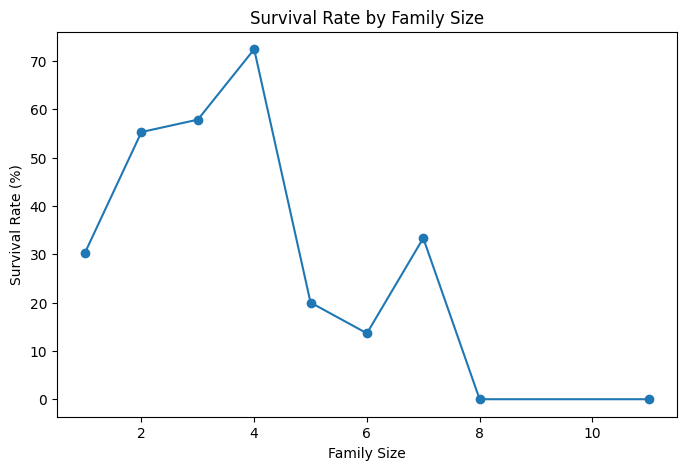

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

survived = df.groupby('Family_size')['Survived'].mean() * 100
plt.figure(figsize=(8,5))
plt.plot(survived.index, survived.values, marker = 'o')

plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Family Size")

plt.show()

In [208]:
df.groupby('Family_size').agg(
    Count=('Survived', 'count'),
    SurvivalRate=('Survived', 'mean')
)

,Count,SurvivalRate
Family_size,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


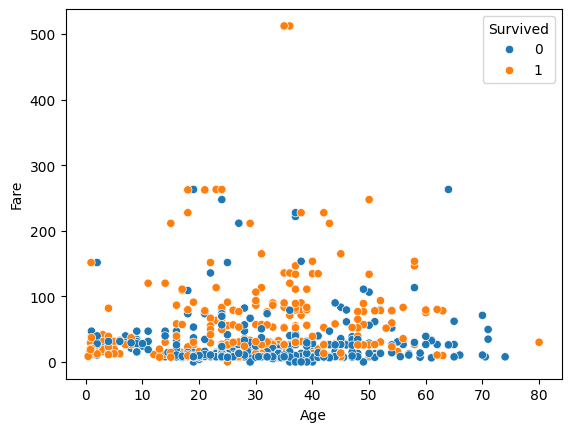

In [215]:
sns.scatterplot(data=df ,x = df['Age'], y = df['Fare'], hue=df['Survived'])
plt.show()

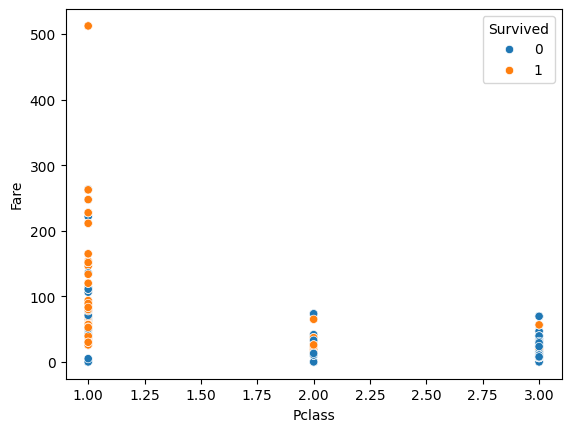

In [217]:
sns.scatterplot(data=df ,x = df['Pclass'], y = df['Fare'], hue=df['Survived'])
plt.show()

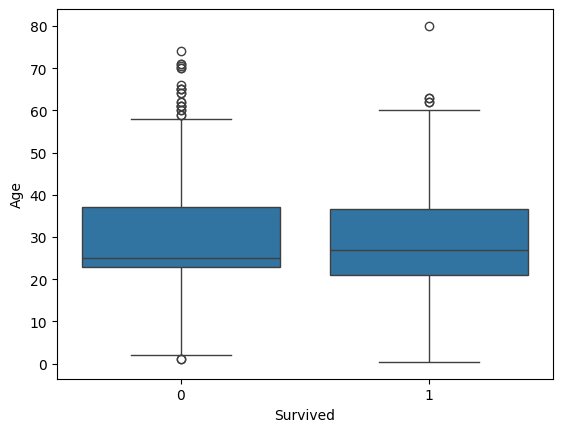

In [220]:
sns.boxplot(data=df , x=df['Survived'] ,y=df['Age'])
plt.show()

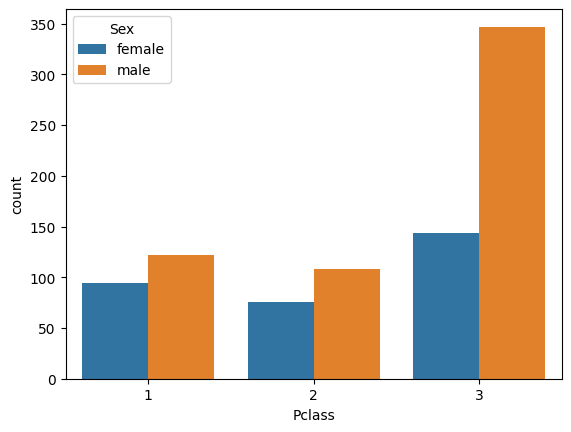

In [223]:
sns.countplot(data=df , x= df['Pclass'] , hue=df['Sex'])
plt.show()

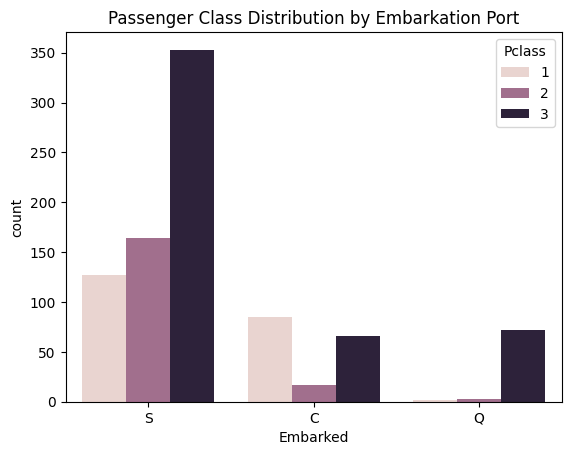

In [227]:
sns.countplot(data=df, x='Embarked', hue='Pclass')
plt.title("Passenger Class Distribution by Embarkation Port")
plt.show()

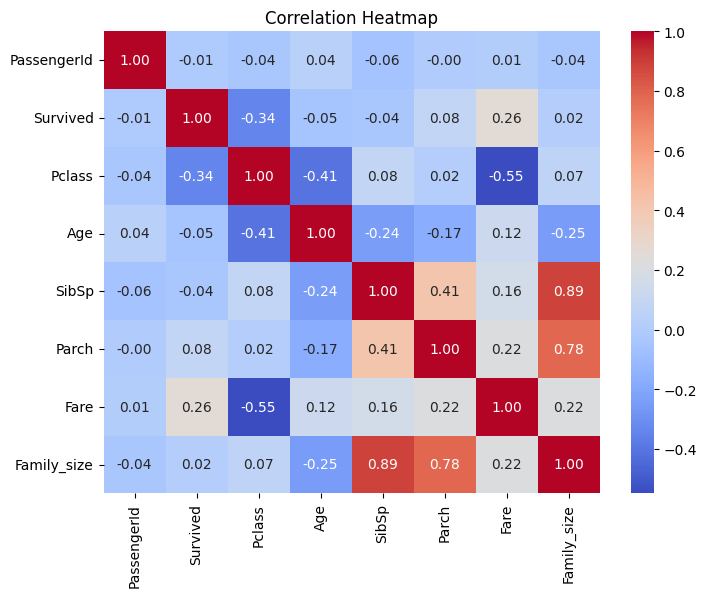

In [228]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()